# Time-Series Forecasting with SARIMA

**Task 05:** End-to-end daily demand forecasting using trend/seasonality analysis, ADF stationarity testing, SARIMA hyperparameter selection, holdout evaluation with RMSE and MAPE, and a 30-day forecast.

The data contains 30 daily observations. Because the data is daily and the pattern repeats weekly, a seasonal period of 7 is used.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

df = pd.read_csv("daily-demand-series.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")
y = df["demand"].astype(float)
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (30, 3)


,demand,marketing_event,holiday
date,,,
2026-06-01,118,0,0
2026-06-02,121,0,0
2026-06-03,125,0,0
2026-06-04,123,0,0
2026-06-05,137,1,0


## 1. Data Quality and Historical Demand

Missing values:


,missing
demand,0
marketing_event,0
holiday,0


Summary statistics:


,demand,marketing_event,holiday
count,30.000000,30.000000,30.000000
mean,142.100000,0.266667,0.133333
std,13.839848,0.449776,0.345746
min,118.000000,0.000000,0.000000
25%,132.500000,0.000000,0.000000
50%,142.000000,0.000000,0.000000
75%,150.250000,0.750000,0.000000
max,174.000000,1.000000,1.000000


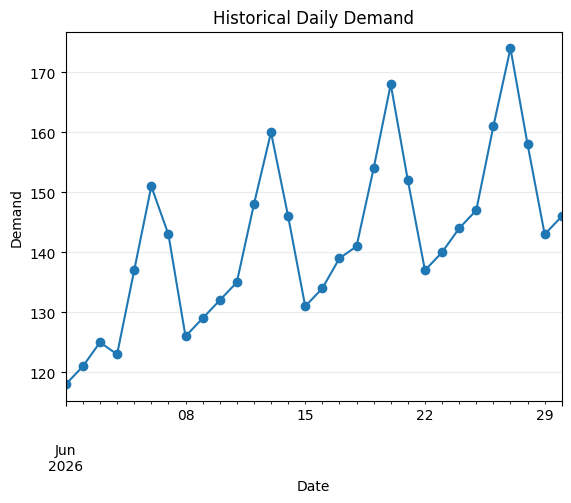

In [2]:
print("Missing values:")
display(df.isna().sum().to_frame("missing"))
print("Summary statistics:")
display(df.describe())
ax=y.plot(marker="o", title="Historical Daily Demand")
ax.set_xlabel("Date"); ax.set_ylabel("Demand"); ax.grid(alpha=.25); plt.show()